In [90]:
import pandas as pd
from tqdm import tqdm
import string
tqdm.pandas()
import spacy
import numpy as np
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import nltk
from nltk.corpus import stopwords
import string
import keras_nlp


In [91]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jainamgada45/indian-government-schemes")

print("Path to dataset files:", path)

data=pd.read_csv(path + "/updated_data.csv")
data.head()

Path to dataset files: /kaggle/input/indian-government-schemes


,scheme_name,slug,details,benefits,eligibility,application,documents,level,schemeCategory,Unnamed: 9,tags
0,"""Immediate Relief Assistance"" under ""Welfare a...",ira-wrflsncs,"The scheme ""Immediate Relief Assistance"" is a ...","₹ 1,00,000, in two installments of ₹ 50,000 ea...",The applicant should be the family (legal heir...,Step 1: The interested applicant should visit ...,Photograph of the Family (Legal Heir) of the M...,State,"Agriculture,Rural & Environment, Social welfar...",NaN,"Missing, Fisherman, Relief, Financial Assistan..."
1,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,astpss,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",The institution should be AICTE approved.,Registration of New Institute: Step 01: Visit ...,Feedback Form Copy of Proceedings Completion R...,Central,Education & Learning,NaN,"Trainings, Financial Assistance, AICTE"
2,Burial and Ex-gratia Payment Scheme in Case of...,baepsicodouldwact,"Launched in 2014, the "" Burial and Ex-gratia P...","Funeral Assistance: ₹3,000 payable in case of ...",The deceased construction worker should have b...,Step 1: The interested applicant should visit ...,Aadhaar Card of the applicant (nominee/Legal h...,State,Social welfare & Empowerment,NaN,"Building Worker, Construction Workers, Unregis..."
3,Consortia & Tender Marketing Scheme,ctms,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,Micro & Small Enterprises registered with NSIC...,"Step 01: The application form, in the prescrib...",A passport size photograph of each of the Prop...,Central,Business & Entrepreneurship,NaN,"Goods And Services Marketing, Turnkey Projects..."
4,Garuda Scheme for Funeral Expense,gsfe,Andhra Pradesh Brahmin Welfare Corporation (AB...,"Financial Assistance of ₹10,000/- for funeral ...",The applicant should be a close relative of th...,Registration and apply Step 01: Applicants hav...,Passport-size Photograph of the Applicant Aadh...,State,Social welfare & Empowerment,NaN,"Social Welfare, Financial Assistance, Deceased..."


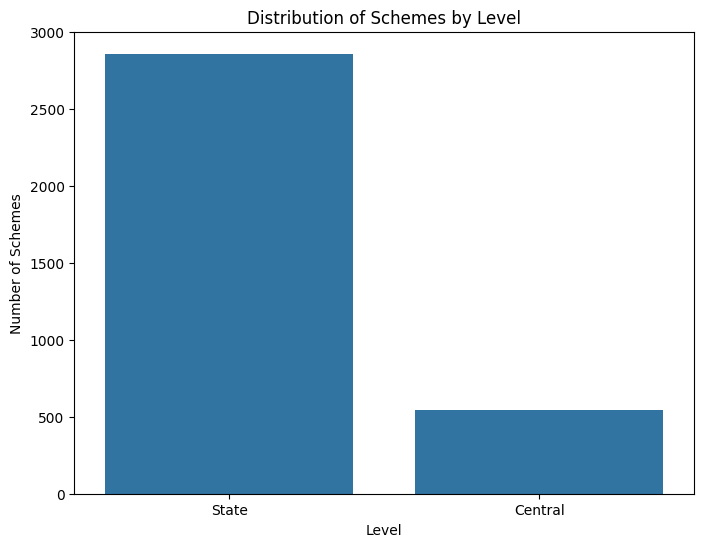

In [ ]:

plt.figure(figsize=(8, 6))
sns.countplot(x='level', data=data)
plt.title('Distribution of Schemes by Level')
plt.xlabel('Level')
plt.ylabel('Number of Schemes')
plt.show()

FOR THIS MVP,**LETS WORK ONLY ON CENTRAL LEVEL SCHEMES**

In [ ]:
df=data[data['level']=="Central"].copy()
df=df.drop(columns=['slug','eligibility','application','level','Unnamed: 9'])

I wanna make a **columns named tokens, now this tokens should include everything in the other columns except schemes**.Coz all the words used in them can be used a keyword, whick we will compare to the input

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df['tokens'] = df['details'] + ' ' + df['benefits'] + ' ' + df['schemeCategory'] + ' ' + df['tags']


In [ ]:
df.head()

,scheme_name,details,benefits,documents,schemeCategory,tags,tokens
0,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",Feedback Form Copy of Proceedings Completion R...,Education & Learning,"Trainings, Financial Assistance, AICTE","Short Term Training Programme-SFURTI Program, ..."
1,Consortia & Tender Marketing Scheme,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,A passport size photograph of each of the Prop...,Business & Entrepreneurship,"Goods And Services Marketing, Turnkey Projects...",Promotion of the product of Micro and Small En...
2,AFFDF-Financial Assistance For Treatment Of Se...,A scheme to provide financial assistance to a ...,Financial assistance for treatment of the appr...,Copies of the following documents duly atteste...,Health & Wellness,"Ex-Servicemen, Widow Of Ex-Servicemen, Serious...",A scheme to provide financial assistance to a ...
3,AICTE - Distinguished Chair Professor Fellowship,A Fellowship Scheme by the All India Council f...,The Fellowship consists of - (i) An honorarium...,Letter of Acceptance 3-5 day schedule to Deliv...,Education & Learning,Fellowship,A Fellowship Scheme by the All India Council f...
4,AICTE - Grant For Augmenting Infrastructure In...,Introduction a. The scheme (operated hitherto ...,The selected institutes will have to complete ...,Essential Documents Required with Application ...,"Education & Learning, Transport & Infrastructure","Grant, Infrastructure",Introduction a. The scheme (operated hitherto ...


We will use bert tokenizer here unlike spacy that we did earlier

In [ ]:

# nltk.download('stopwords')
# stopwords = set(stopwords.words('english'))


# tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
# text = 'ChatGPT is a language model developed by OpenAI, based on the GPT (Generative Pre-trained Transformer) architecture. '

# # Tokenize and encode the text
# encoding = tokenizer.encode(text)
# print("Token IDs:", encoding)

# # Convert token IDs back to tokens
# tokens = tokenizer.convert_ids_to_tokens(encoding)
# tokens=[i for i in tokens if i not in string.punctuation]
# print("Tokens:", tokens)

Token IDs: [101, 24705, 1204, 17095, 1942, 1110, 170, 1846, 2235, 1872, 1118, 3353, 1592, 2240, 117, 1359, 1113, 1103, 15175, 1942, 113, 9066, 15306, 11689, 118, 3972, 13809, 23763, 114, 4220, 119, 102]
Tokens: ['[CLS]', 'Cha', '##t', '##GP', '##T', 'is', 'a', 'language', 'model', 'developed', 'by', 'Open', '##A', '##I', 'based', 'on', 'the', 'GP', '##T', 'Gene', '##rative', 'Pre', 'trained', 'Trans', '##former', 'architecture', '[SEP]']


the tokens here may seen abnormal, they are not is Word piece tokenization which is pretty normal in BERT

In [ ]:
# preprocessor = keras_nlp.models.BertPreprocessor.from_preset("bert_base_en_uncased",trainable=True)
# encoder = keras_nlp.models.BertBackbone.from_preset("bert_base_en_uncased")

In [ ]:
# def get_sentence_embeding(sentences):
#     preprocessed_text = preprocessor(sentences)
#     return encoder(preprocessed_text)['pooled_output']

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
df.shape

(541, 7)

In [ ]:
df["embeddings"] = None # Create an empty 'embeddings' column

for i in range(df.shape[0]):
  scheme_text = df["tokens"].iloc[i] # Changed index to i
  if isinstance(scheme_text, str): # Check if scheme_text is a string
    scheme_embedding = model.encode(scheme_text, convert_to_tensor=True)
    df["embeddings"].iloc[i] = scheme_embedding # Store the embedding using iloc

Streaming output truncated to the last 5000 lines.

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["embeddings"].iloc[i] = scheme_embedding # Store the embedding using iloc
/tmp/ipython-input-3174160242.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"

In [ ]:
df.head()

,scheme_name,details,benefits,documents,schemeCategory,tags,tokens,embeddings
0,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",Feedback Form Copy of Proceedings Completion R...,Education & Learning,"Trainings, Financial Assistance, AICTE","Short Term Training Programme-SFURTI Program, ...","[tensor(0.0098), tensor(-0.0252), tensor(-0.04..."
1,Consortia & Tender Marketing Scheme,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,A passport size photograph of each of the Prop...,Business & Entrepreneurship,"Goods And Services Marketing, Turnkey Projects...",Promotion of the product of Micro and Small En...,"[tensor(-0.0208), tensor(-0.0242), tensor(-0.0..."
2,AFFDF-Financial Assistance For Treatment Of Se...,A scheme to provide financial assistance to a ...,Financial assistance for treatment of the appr...,Copies of the following documents duly atteste...,Health & Wellness,"Ex-Servicemen, Widow Of Ex-Servicemen, Serious...",A scheme to provide financial assistance to a ...,"[tensor(-0.0358), tensor(0.0189), tensor(-0.02..."
3,AICTE - Distinguished Chair Professor Fellowship,A Fellowship Scheme by the All India Council f...,The Fellowship consists of - (i) An honorarium...,Letter of Acceptance 3-5 day schedule to Deliv...,Education & Learning,Fellowship,A Fellowship Scheme by the All India Council f...,"[tensor(-0.0399), tensor(0.0350), tensor(-0.05..."
4,AICTE - Grant For Augmenting Infrastructure In...,Introduction a. The scheme (operated hitherto ...,The selected institutes will have to complete ...,Essential Documents Required with Application ...,"Education & Learning, Transport & Infrastructure","Grant, Infrastructure",Introduction a. The scheme (operated hitherto ...,"[tensor(-0.0528), tensor(0.1082), tensor(0.009..."


In [ ]:
null_embeddings_indices = df[df['embeddings'].isnull()].index.tolist()
print(null_embeddings_indices)

[38, 429, 520]


In [ ]:
sentence_emb = model.encode([text], convert_to_tensor=True)

In [ ]:
for i in null_embeddings_indices:
  df['tokens'][i] = df['details'][i] + ' ' + df['benefits'][i] + ' ' + df['schemeCategory'][i]

/tmp/ipython-input-1572812283.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['tokens'][i] = df['details'][i] + ' ' + df['benefits'][i] + ' ' + df['schemeCategory'][i]
/tmp/ipython-input-1572812283.py:2: FutureWarning: ChainedAssignme

In [ ]:
for i in null_embeddings_indices:
  scheme_text = df["tokens"].iloc[i]
  if isinstance(scheme_text, str):
    scheme_embedding = model.encode(scheme_text, convert_to_tensor=True)
    df["embeddings"].iloc[i] = scheme_embedding

/tmp/ipython-input-2995295470.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["embeddings"].iloc[i] = scheme_embedding
/tmp/ipython-input-2995295470.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You

In [ ]:
null_embeddings_indices = df[df['embeddings'].isnull()].index.tolist()

In [94]:
df.to_pickle("embeddings_new.pkl")


In [ ]:
df.head()

,scheme_name,details,benefits,documents,schemeCategory,tags,tokens,embeddings
0,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",Feedback Form Copy of Proceedings Completion R...,Education & Learning,"Trainings, Financial Assistance, AICTE","Short Term Training Programme-SFURTI Program, ...","[tensor(0.0098), tensor(-0.0252), tensor(-0.04..."
1,Consortia & Tender Marketing Scheme,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,A passport size photograph of each of the Prop...,Business & Entrepreneurship,"Goods And Services Marketing, Turnkey Projects...",Promotion of the product of Micro and Small En...,"[tensor(-0.0208), tensor(-0.0242), tensor(-0.0..."
2,AFFDF-Financial Assistance For Treatment Of Se...,A scheme to provide financial assistance to a ...,Financial assistance for treatment of the appr...,Copies of the following documents duly atteste...,Health & Wellness,"Ex-Servicemen, Widow Of Ex-Servicemen, Serious...",A scheme to provide financial assistance to a ...,"[tensor(-0.0358), tensor(0.0189), tensor(-0.02..."
3,AICTE - Distinguished Chair Professor Fellowship,A Fellowship Scheme by the All India Council f...,The Fellowship consists of - (i) An honorarium...,Letter of Acceptance 3-5 day schedule to Deliv...,Education & Learning,Fellowship,A Fellowship Scheme by the All India Council f...,"[tensor(-0.0399), tensor(0.0350), tensor(-0.05..."
4,AICTE - Grant For Augmenting Infrastructure In...,Introduction a. The scheme (operated hitherto ...,The selected institutes will have to complete ...,Essential Documents Required with Application ...,"Education & Learning, Transport & Infrastructure","Grant, Infrastructure",Introduction a. The scheme (operated hitherto ...,"[tensor(-0.0528), tensor(0.1082), tensor(0.009..."
